In [3]:
import numpy 
from matplotlib import pyplot

In [5]:
length = 10             # Assume a 10 meter rod
k = 0.89                # heat capacity (J/g Celsius) of aluminium:0.89. Alternatives e.g. mercury:0.14, copper:0.385, air:1.012, helium:5.1932 

# Boundary Condition
temp_left = 100         # temperature at the left end of the rod
temp_right = 200        # temperature at the right end of the rod
total_sim_time = 10

In [16]:
# Set change in x (dx), i.e. 10cm shifts over the rod
dx = .1

# Calculate grid points
x_vector = numpy.linspace(0, length, int(length/dx))
#x_vector = numpy.linspace(0, length, 101)      # Set num=101 for even 0.1 steps

In [17]:
x_vector

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

In [24]:
# Set change in time (dt)
dt = 0.0001
print('Time steps: ' + str(int(total_sim_time/dt)))
t_vector = numpy.linspace(0, total_sim_time, int(total_sim_time/dt))
t_vector

Time steps: 100000


array([0.00000e+00, 1.00001e-04, 2.00002e-04, ..., 9.99980e+00,
       9.99990e+00, 1.00000e+01])

In [25]:
# Initial Condition
u = numpy.zeros([len(t_vector),len(x_vector)])

# shape of u: (rows, columns) = (time steps, space steps)
u.shape

(100000, 100)

In [11]:
u

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
# Set entry (0,0) of matrix u to 100
u[0,0] = 100
u

In [26]:
# Set left and right side of the rod to 100 and 200, respectively, for all points in time t (rows)
u[:,0] = temp_left
u[:,-1] = temp_right        # -1 indicates the last column
u

array([[100.,   0.,   0., ...,   0.,   0., 200.],
       [100.,   0.,   0., ...,   0.,   0., 200.],
       [100.,   0.,   0., ...,   0.,   0., 200.],
       ...,
       [100.,   0.,   0., ...,   0.,   0., 200.],
       [100.,   0.,   0., ...,   0.,   0., 200.],
       [100.,   0.,   0., ...,   0.,   0., 200.]])

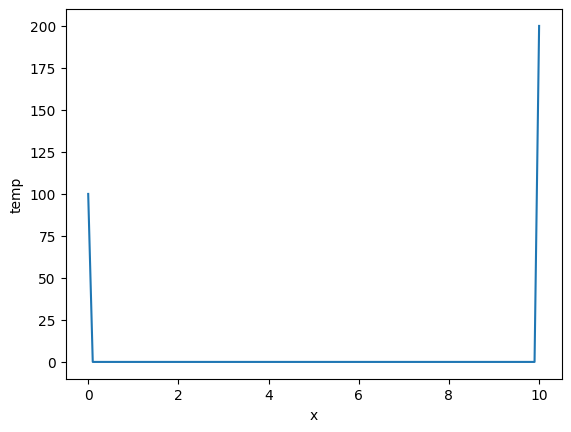

In [27]:
pyplot.plot(x_vector,u[0])
pyplot.ylabel("temp")
pyplot.xlabel("x")
pyplot.show()

\begin{equation}
    \begin{split}
    \frac{\partial u}{\partial t} &= k \frac{\partial^2 u}{\partial x^2} \\[2em]
    f'(x) &= \frac{f(x+h) - f(x)}{h} \\[2em]
    f''(x) &= \frac{f(x+h) - 2f(x) + f(x-h)}{h^2} \\[2em]
    \frac{u(t + dt, x) - u(t,x)}{dt} &= k \frac{u(t,x+dx) - 2u(t,x) + u(t,x-dx)}{dx^2}
    \end{split}
\end{equation}

Rearrange the last equation for $u(t + dt, x)$:

\begin{equation}
    \begin{split}
    u(t + dt, x) &= u(t,x) + k \cdot \frac{u(t,x+dx) - 2u(t,x) + u(t,x-dx)}{dx^2} \cdot dt
    \end{split}
\end{equation}

In [31]:
const = (k * (dt/dx**2))                    # Since k, dt and dx are constant, take the factor out of the loop to enhance perforamcne

# Start counting from 1 (not 0) because of boundary condition; u[t,x-1] would result in an index error for x=0
for t in range(1, len(t_vector)-1):         # -1 because we start at index 0 (rather than 1) and have to shift the 'upper bound' accordingly
    for x in range(1, len(x_vector)-1):
        u[t+1,x] = (const * (u[t, x+1] - 2*u[t,x] + u[t,x-1])) + u[t,x]

u

array([[100.        ,   0.        ,   0.        , ...,   0.        ,
          0.        , 200.        ],
       [100.        ,   0.        ,   0.        , ...,   0.        ,
          0.        , 200.        ],
       [100.        ,   0.89      ,   0.        , ...,   0.        ,
          1.78      , 200.        ],
       ...,
       [100.        ,  98.59123721,  97.1847561 , ..., 192.92058415,
        196.4589255 , 200.        ],
       [100.        ,  98.59125751,  97.1847967 , ..., 192.92063276,
        196.45894983, 200.        ],
       [100.        ,  98.59127782,  97.1848373 , ..., 192.92068138,
        196.45897415, 200.        ]])

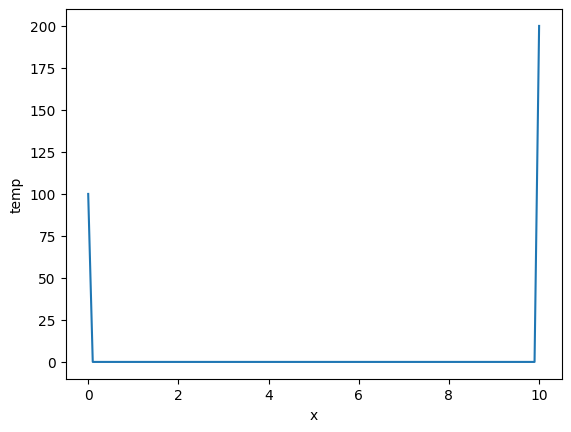

In [32]:
pyplot.plot(x_vector,u[0])
pyplot.ylabel("temp")
pyplot.xlabel("x")
pyplot.show()

In [22]:
len(u)

100000

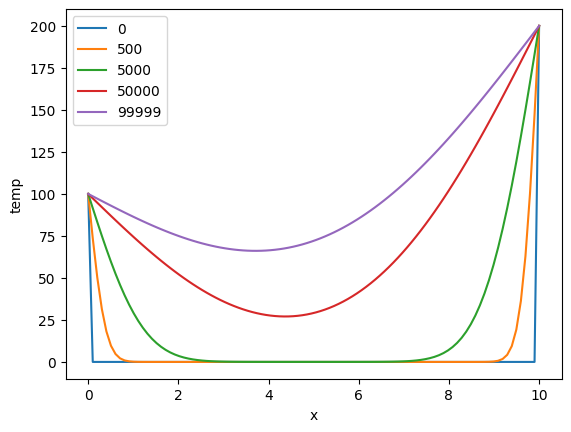

In [59]:
# Plot the temperature at different time steps. min = 0;   max = len(u)-1 = int(total_sim_time/dt)-1

time_step_list = [0, 500, 5000, 50000, 99999]
for t in time_step_list:
    pyplot.plot(x_vector,u[t])
pyplot.legend(time_step_list)
pyplot.ylabel("temp")
pyplot.xlabel("x")
pyplot.show()